# Individual core gene expression

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse

sns.set_theme(style='whitegrid', context='talk')


In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

ADATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'merged' / 'adata_merged_pb_26donors.h5ad'
FIGURE_DIR = PROJECT_ROOT / 'results' / '11_Individual core gene expression_26donors'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Settings

In [9]:
CONDITION_TO_INCLUDE = 'Control'
COUNT_LAYER = 'counts'
DOTPLOT_TARGET_SUM = 1e4
SAVE_DOTPLOTS = False

GENE_SETS = {
    'CSW': ['C9orf72', 'SMCR8', 'WDR41'],
    'ULK_FIP200': ['RB1CC1', 'ULK1', 'ULK2', 'ATG13', 'ATG101'],
    'innate_immune': ['TBK1', 'CGAS', 'STING1', 'IRF3'],
    'housekeeping': ['GAPDH', 'ACTB'],
}

BROAD_CLASSES_TO_PLOT = ['Excitatory', 'Inhibitory', 'Glia']
SUBTYPES_TO_PLOT = [
    'Ex.L5.PCP4_NXPH2',
    'Ex.L5_L6.THEMIS_NR4A2',
    'Ex.L5_L6.THEMIS_TMEM233',
    'Ex.L6.TLE4_CCBE1',
    'Ex.L6.TLE4_MEGF11',
    'Glia.Micro',
    'Glia.Oligo',
    'Glia.Astro.GFAP.neg', 
    'Glia.Astro.GFAP.pos',
]

GENES_TO_COMPARE = [gene for genes in GENE_SETS.values() for gene in genes]
GROUP_COL_FOR_BARS = 'cell_subtype'  # 'cell_class_major_harmony' for broad classes, 'cell_subtype' for subtypes
CELL_TYPES_FOR_BARS = SUBTYPES_TO_PLOT


## Load data and inspect annotations


In [4]:
adata = sc.read_h5ad(ADATA_PATH)

required = ['condition', 'sample', 'cell_class_major_harmony', 'cell_subtype']
missing = [col for col in required if col not in adata.obs]
if missing:
    raise KeyError(f'Missing required obs columns: {missing}')
if COUNT_LAYER not in adata.layers:
    raise KeyError(f'{COUNT_LAYER!r} not found in adata.layers')

print(adata)
print()
print('Available conditions:')
display(adata.obs['condition'].astype(str).value_counts().sort_index())


AnnData object with n_obs × n_vars = 163784 × 61552
    obs: 'sample', 'condition', 'dataset', 'tissue', 'source_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outliers', 'mt_outliers', 'high_quality_cells', 'soupx_clusters', 'doublet_score_scrublet', 'predicted_doublet_scrublet', 'barcode', 'merge_key', 'leiden_harmony', 'cell_class_major_harmony', 'cell_subtype'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb'
    obsm: 'X_pca_harmony', 'X_umap'
    layers: 'counts', 'raw_counts', 'soupx_counts'

Available conditions:


condition
Control    41994
c9ALS      42267
sALS       79523
Name: count, dtype: int64

In [10]:
annotation_table = (
    adata.obs
    .assign(
        broad_class=adata.obs['cell_class_major_harmony'].astype(str),
        subtype=adata.obs['cell_subtype'].astype(str),
    )
    .groupby(['broad_class', 'subtype'], observed=True)
    .size()
    .reset_index(name='n_cells')
    .sort_values(['broad_class', 'subtype'])
)
display(annotation_table)


,broad_class,subtype,n_cells
0,Excitatory,Ex.L2_L3.CUX2_RASGRF2,14924
1,Excitatory,Ex.L4_L5.RORB_POU3F2,4945
2,Excitatory,Ex.L4_L6.RORB_LRRK1,3671
3,Excitatory,Ex.L5.PCP4_NXPH2,872
4,Excitatory,Ex.L5_L6.THEMIS_NR4A2,840
5,Excitatory,Ex.L5_L6.THEMIS_TMEM233,3660
6,Excitatory,Ex.L6.TLE4_CCBE1,1480
7,Excitatory,Ex.L6.TLE4_MEGF11,1651
8,Glia,Glia.Astro.GFAP.neg,14239
9,Glia,Glia.Micro,6697


In [11]:
adata_condition = adata[adata.obs['condition'].astype(str).eq(CONDITION_TO_INCLUDE)].copy()
print(f'Nuclei retained for {CONDITION_TO_INCLUDE}: {adata_condition.n_obs:,}')


Nuclei retained for Control: 41,994


## Dotplots

Dot size is the fraction of cells expressing the gene. Colour is mean normalized expression after library-size normalization within the selected condition.


In [7]:
def present_genes(genes, var_names):
    lookup = {gene.upper(): gene for gene in pd.Index(var_names).astype(str)}
    matched = [lookup[gene.upper()] for gene in genes if gene.upper() in lookup]
    missing = [gene for gene in genes if gene.upper() not in lookup]
    if missing:
        print('Missing genes skipped:', missing)
    return matched


def make_dotplot(genes, groupby_col, groups_to_plot, title, output_name=None):
    genes = present_genes(genes, adata_condition.var_names)
    if not genes:
        raise ValueError('None of the requested genes were found.')

    group_values = adata_condition.obs[groupby_col].astype(str)
    mask = group_values.isin(groups_to_plot)
    adata_plot = adata_condition[mask, :].copy()
    adata_plot.obs['plot_group'] = pd.Categorical(group_values.loc[mask], categories=groups_to_plot, ordered=True)

    total_counts = np.asarray(adata_plot.layers[COUNT_LAYER].sum(axis=1)).ravel()
    scale = np.divide(DOTPLOT_TARGET_SUM, total_counts, out=np.zeros_like(total_counts, dtype=float), where=total_counts > 0)
    x = adata_plot[:, genes].layers[COUNT_LAYER].copy()
    if sparse.issparse(x):
        x = x.multiply(scale[:, None]).tocsr()
    else:
        x = x * scale[:, None]
    adata_plot = adata_plot[:, genes].copy()
    adata_plot.X = x
    sc.pp.log1p(adata_plot)

    fig_width = max(9, 1.6 * len(groups_to_plot))
    fig_height = max(4, 0.4 * len(genes) + 2.5)
    dp = sc.pl.dotplot(
        adata_plot,
        var_names=genes,
        groupby='plot_group',
        swap_axes=True,
        cmap='YlOrRd',
        return_fig=True,
        show=False,
        figsize=(fig_width, fig_height),
        size_title='Fraction of cells\nin group (%)',
        colorbar_title='Mean expression\nin group',
    )
    dp.style(dot_min=0, dot_max=1, size_exponent=0.5)
    dp.legend(width=3.8)
    dp.make_figure()

    ax = dp.get_axes()['mainplot_ax']
    ax.set_title(title, pad=18, fontsize=13)
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='x', labeltop=True, labelbottom=False, rotation=60, labelsize=10)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('left')
        label.set_verticalalignment('bottom')

    if SAVE_DOTPLOTS and output_name:
        dp.fig.savefig(FIGURE_DIR / output_name, bbox_inches='tight', pad_inches=0.35)
    return adata_plot, dp


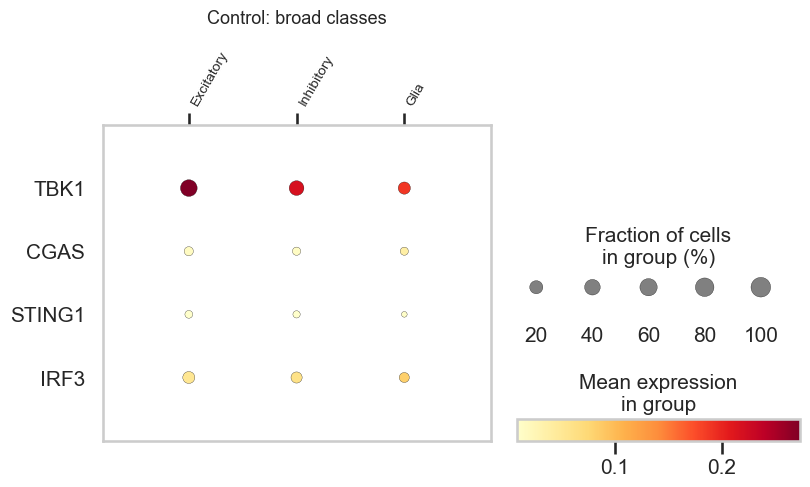

In [16]:
GENE_SETS = {
    'CSW': ['C9orf72', 'SMCR8', 'WDR41'],
    'ULK_FIP200': ['RB1CC1', 'ULK1', 'ULK2', 'ATG13', 'ATG101'],
    'innate_immune': ['TBK1', 'CGAS', 'STING1', 'IRF3'],
    'housekeeping': ['GAPDH', 'ACTB'],
}

genes = GENE_SETS['innate_immune']

adata_broad_dotplot, broad_dotplot = make_dotplot(
    genes=genes,
    groupby_col='cell_class_major_harmony',
    groups_to_plot=BROAD_CLASSES_TO_PLOT,
    title=f'{CONDITION_TO_INCLUDE}: broad classes',
    output_name=f'CSW_broad_{CONDITION_TO_INCLUDE}.pdf',
)


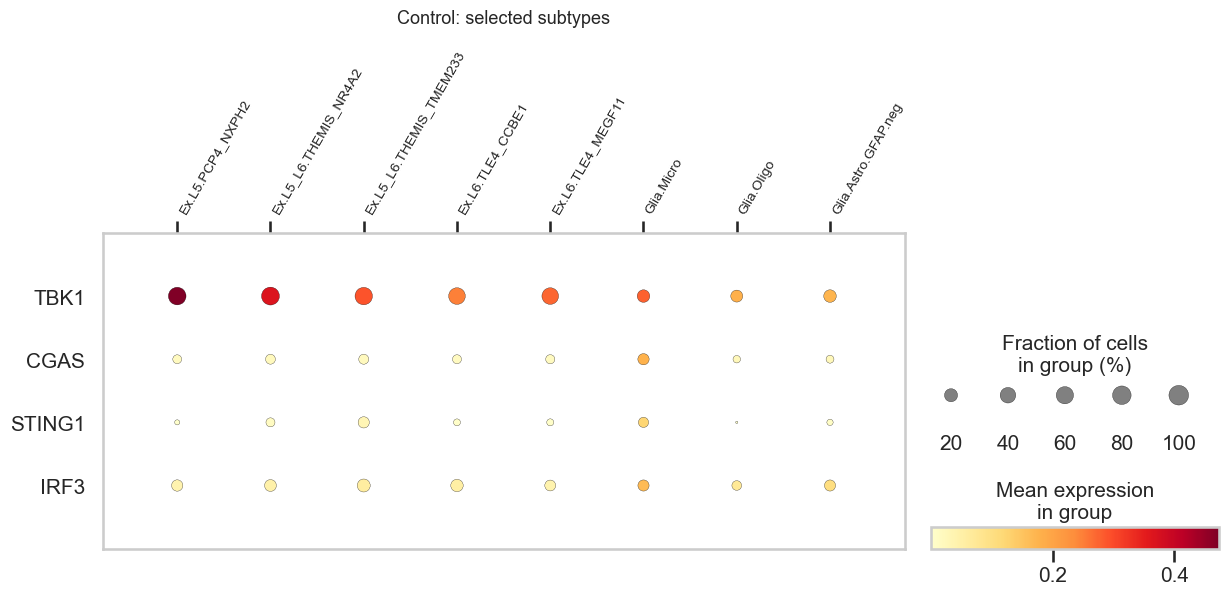

In [17]:

adata_subtype_dotplot, subtype_dotplot = make_dotplot(
    genes=genes,
    groupby_col='cell_subtype',
    groups_to_plot=SUBTYPES_TO_PLOT,
    title=f'{CONDITION_TO_INCLUDE}: selected subtypes',
    output_name=f'CSW_subtypes_{CONDITION_TO_INCLUDE}.pdf',
)

## Donor-level expression bar charts

Each point is one donor-level pseudobulk value. Bars show mean logCPM and error bars show standard error across donors.


In [18]:
gene_lookup = {gene.upper(): gene for gene in adata.var_names.astype(str)}
matched = {gene: gene_lookup[gene.upper()] for gene in GENES_TO_COMPARE if gene.upper() in gene_lookup}
missing = [gene for gene in GENES_TO_COMPARE if gene.upper() not in gene_lookup]
if missing:
    print('Missing genes skipped:', missing)
rows = []

for cell_type in CELL_TYPES_FOR_BARS:
    mask = adata_condition.obs[GROUP_COL_FOR_BARS].astype(str).eq(cell_type)
    adata_cell = adata_condition[mask].copy()
    if adata_cell.n_obs == 0:
        print(f'No cells found for {cell_type}; skipped.')
        continue

    counts = adata_cell.layers[COUNT_LAYER]
    total_per_cell = np.asarray(counts.sum(axis=1)).ravel()
    samples = adata_cell.obs['sample'].astype(str)

    for sample in samples.unique():
        sample_mask = samples.eq(sample).to_numpy()
        library_size = total_per_cell[sample_mask].sum()
        if library_size <= 0:
            continue
        for requested_gene, matched_gene in matched.items():
            gene_idx = adata_cell.var_names.get_loc(matched_gene)
            gene_counts = counts[sample_mask, gene_idx].sum()
            rows.append({
                'cell_type': cell_type,
                'sample': sample,
                'gene': requested_gene,
                'logCPM': np.log1p(float(gene_counts) / library_size * 1e6),
            })

gene_expression = pd.DataFrame(rows)
display(gene_expression.head())


No cells found for Glia.Astro.GFAP.pos; skipped.


,cell_type,sample,gene,logCPM
0,Ex.L5.PCP4_NXPH2,GSM5292174,C9orf72,4.402307
1,Ex.L5.PCP4_NXPH2,GSM5292174,SMCR8,2.182587
2,Ex.L5.PCP4_NXPH2,GSM5292174,WDR41,4.244020
3,Ex.L5.PCP4_NXPH2,GSM5292174,RB1CC1,4.992740
4,Ex.L5.PCP4_NXPH2,GSM5292174,ULK1,3.698208


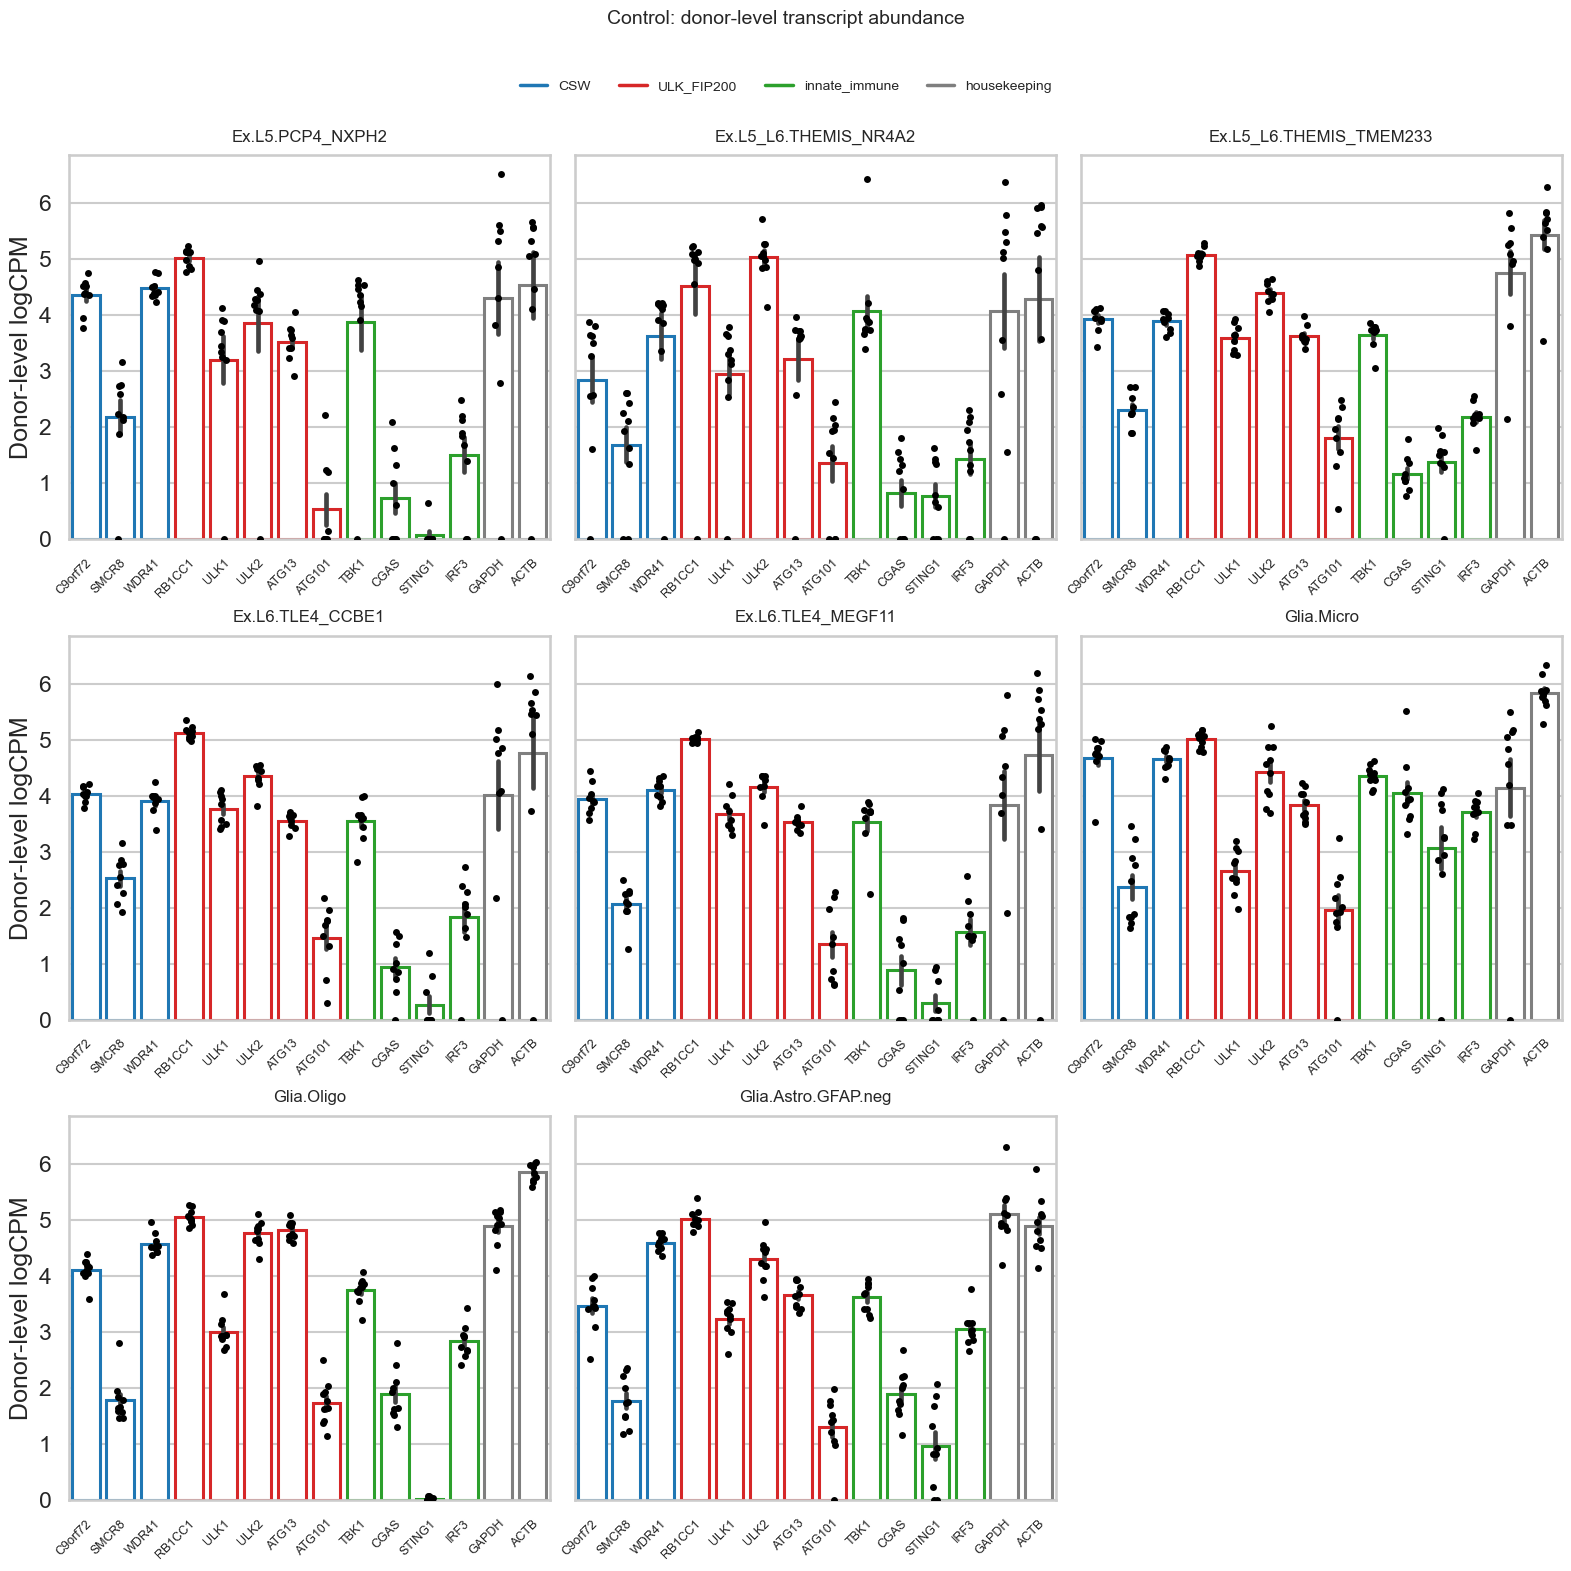

In [19]:
N_COLS = 3
PANEL_WIDTH = 5.2
PANEL_HEIGHT = 4.8
X_LABEL_FONTSIZE = 9

MODULE_COLOURS = {
    'CSW': '#1f77b4',
    'ULK_FIP200': '#d62728',
    'innate_immune': '#2ca02c',
    'housekeeping': '#7f7f7f',
}
gene_to_colour = {
    gene: MODULE_COLOURS[module]
    for module, genes in GENE_SETS.items()
    if module in MODULE_COLOURS
    for gene in genes
}

cell_types_present = gene_expression['cell_type'].drop_duplicates().tolist()
genes_present = gene_expression['gene'].drop_duplicates().tolist()
n_panels = len(cell_types_present)
n_cols = min(N_COLS, n_panels)
n_rows = int(np.ceil(n_panels / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(PANEL_WIDTH * n_cols, PANEL_HEIGHT * n_rows),
    sharey=True,
    constrained_layout=True,
)
axes = np.asarray(axes).ravel()

for ax, cell_type in zip(axes, cell_types_present):
    plot_df = gene_expression.query('cell_type == @cell_type')
    sns.barplot(
        data=plot_df,
        x='gene',
        y='logCPM',
        order=genes_present,
        errorbar='se',
        color='white',
        edgecolor='black',
        linewidth=1.8,
        ax=ax,
    )
    for patch, gene in zip(ax.patches, genes_present):
        patch.set_facecolor('white')
        patch.set_edgecolor(gene_to_colour.get(gene, 'black'))
        patch.set_linewidth(2.2)
    sns.stripplot(
        data=plot_df,
        x='gene',
        y='logCPM',
        order=genes_present,
        color='black',
        size=5,
        jitter=True,
        ax=ax,
    )
    ax.set_title(cell_type, fontsize=12, pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Donor-level logCPM')
    ax.tick_params(axis='x', rotation=45, labelsize=X_LABEL_FONTSIZE)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
        label.set_rotation_mode('anchor')

for ax in axes[n_panels:]:
    ax.remove()

handles = [plt.Line2D([0], [0], color=colour, linewidth=2.5, label=module) for module, colour in MODULE_COLOURS.items()]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.04), ncol=min(4, len(handles)), frameon=False, fontsize=10)
fig.suptitle(f'{CONDITION_TO_INCLUDE}: donor-level transcript abundance', fontsize=14, y=1.08)
plt.show()
